In [ ]:
import os
import mne
import scipy
import numpy as np
import matplotlib.pyplot as plt

from utils.utils import crop_brain_and_make_transparent, mm_to_inches
from utils.configs import NUM_VERTEX_DICT

plt.rcParams["font.family"] = "Arial"

# Parameters
SUBJECTS_DIR = "./freesurfer"
SUBJECT = "fsaverage"
RESULTS_ROOT = "./results"
ALPHA = 0.001
SPACING = "ico4"
NUM_VERTEX = NUM_VERTEX_DICT[SPACING]
P_THRESH = 0.05

Using pyvistaqt 3d backend.



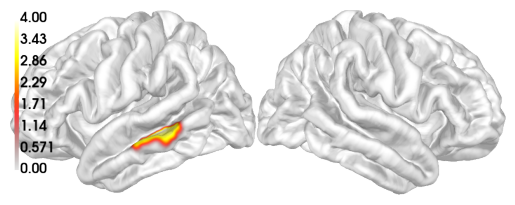

In [2]:
# Visualize
results_dir = os.path.join(RESULTS_ROOT, "7.1-Pretarget_Activation")
npy_dir = os.path.join(results_dir, "npy")
stc_dir = os.path.join(results_dir, "stc")
img_dir = os.path.join(results_dir, "img")

os.makedirs(img_dir, exist_ok=True)

duration_stc = mne.read_source_estimate(os.path.join(stc_dir, f"T-obs-all_alpha-{ALPHA}"))

brain = duration_stc.plot(
    hemi="split",
    subjects_dir=SUBJECTS_DIR,
    subject=SUBJECT,
    colormap="hot",
    colorbar=True,
    views="lateral",
    size=(800, 400),
    initial_time=0,
    smoothing_steps=15,
    background="white",
    transparent=True,
    cortex=[0.9, 0.9, 0.9],
    surface="pial",
    clim=dict(kind="value", lims=[0, 2, 4])
)

image = brain.screenshot()
fig_brain = crop_brain_and_make_transparent(image)
fig_brain.savefig(os.path.join(img_dir, f"brainplot.svg"),
                  transparent=True, dpi=600, format="svg", bbox_inches="tight")

plt.show()

In [4]:
# Extract the ROI label
lh_orig_vertices = duration_stc.vertices[0]
lh_data = duration_stc.data[:len(duration_stc.vertices[0]), :]
lh_data = np.mean(np.abs(lh_data), axis=1)
roi_vertices = lh_orig_vertices[np.where(lh_data > 0)[0]]

roi_label = mne.Label(
    vertices=roi_vertices,
    hemi="lh",
    subject=SUBJECT,
    comment="NonZero_LH_ROI",
    name="MTG-lh"
)

roi_label.save(os.path.join(results_dir, "MTG-lh.label"))

Saving label to : ./results\7.1-Pretarget_Activation\MTG-lh.label


    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read

############## MTG-lh ##############
Using a threshold of 2.034515
stat_fun(H1): min=-1.277971 max=4.813192
Running initial clustering …
Found 10 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 3.125s-3.390s


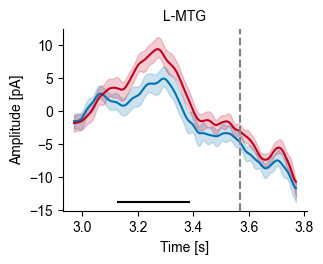

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(mm_to_inches(80, 60)))
title = "L-MTG"

stc_data = np.load(os.path.join(npy_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(npy_dir, "time_vector.npy"))

sta_data = stc_data[:, 0, :, :]
dev_data = stc_data[:, 1, :, :]

onset = 3.57

src = mne.read_source_spaces(os.path.join(
    SUBJECTS_DIR, SUBJECT,
    "bem", f"{SUBJECT}-{SPACING}-src.fif"
))

print("\n" + "#" * 14 + " " + roi_label.name + " " + "#" * 14)
if roi_label.hemi == "lh":
    vertices_inds = roi_label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
else:
    vertices_inds = roi_label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2

flip = mne.label_sign_flip(roi_label, src)

dev_timeseries = (dev_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
sta_timeseries = (sta_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

X = dev_timeseries - sta_timeseries
T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
    X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
)

sta_mean = sta_timeseries.mean(axis=0)
sta_se = sta_timeseries.std(axis=0) / np.sqrt(sta_timeseries.shape[0])

dev_mean = dev_timeseries.mean(axis=0)
dev_se = dev_timeseries.std(axis=0) / np.sqrt(dev_timeseries.shape[0])

ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(sta_mean, sigma=2), color="#0072b2", linewidth=1.5, label="STA")
ax.fill_between(time_vector, sta_mean - sta_se, sta_mean + sta_se, color="#0072b2", alpha=0.2)

ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(dev_mean, sigma=2), color="#C10020", linewidth=1.5, label="DEV")
ax.fill_between(time_vector, dev_mean - dev_se, dev_mean + dev_se, color="#C10020", alpha=0.2)

ax.set_title(title, fontsize=10)

sig_y = min(sta_mean.min(), dev_mean.min()) - 1.5
for clu_idx, clu in enumerate(clusters):
    if p_values[clu_idx] < P_THRESH:
        t_inds = clu[0]
        start_time = time_vector[t_inds[0]]
        end_time = time_vector[t_inds[-1]]
        if end_time - start_time < 0.1:
            continue
        print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
        ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)

ax.set_xlabel("Time [s]", fontsize=10)
ax.set_ylabel("Amplitude [pA]", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(onset, linestyle="--", color="gray")

plt.show()